# ***Multimodal CTR Prediction using Deep Learning***

---

### Course Code: CSC5376  
### Project: Task 1 & Task 2 – CTR Prediction  
### Supervised by: Pr. El Habib Nfaoui  

### Group Members:
- Aya Ismaili  
- Khawla Chrifi Alaoui  
- Rania Khaoudane  

---

## Overview

This project focuses on predicting user interaction (Click-Through Rate) using a combination of structured features and pretrained multimodal embeddings.

We propose a deep learning approach that integrates:
- User behavioral signals  
- Item metadata  
- Pretrained semantic representations  

The objective is to model complex user-item interactions and improve ranking performance in a recommendation setting.

---

## Objective

The goal of this project is to design a robust CTR prediction model capable of estimating the probability that a user will interact with a given item.

This task is formulated as a **binary classification problem**, where:
- Input: user-item interaction features  
- Output: probability of interaction  

A key challenge is to effectively combine heterogeneous data sources:
- Sparse categorical features (user IDs, item IDs)
- Interaction signals (likes, views)
- Dense pretrained embeddings (multimodal item representations)

---

## Key Idea

We leverage a hybrid approach combining:
- **Learned embeddings** → capture user/item-specific patterns (memorization)
- **Pretrained embeddings** → capture semantic similarity between items (generalization)
- **Deep neural networks (MLP)** → model nonlinear interactions

This design balances expressiveness and generalization.

---

## Evaluation Metric
We use **AUC (Area Under the ROC Curve)** to evaluate performance, which measures ranking quality between positive and negative samples.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Data Loading and Exploration

We begin by loading the dataset from Google Drive and extracting the required files.

## Dataset Description

The dataset consists of large-scale user-item interactions and includes:

- **Train set** (~3.6M samples): used for model training  
- **Validation set**: used for hyperparameter tuning  
- **Test set**: used for final evaluation (submission)  
- **Item metadata**: additional item-level information  
- **Pretrained embeddings**: 128-dimensional multimodal representations  

---

## Dataset Characteristics

- Large-scale dataset (millions of interactions)
- Mix of categorical and numerical features
- Precomputed semantic embeddings for items

This combination makes the problem suitable for **deep learning-based recommendation models**.

In [3]:
import zipfile
from pathlib import Path

zip_path = Path("/content/drive/MyDrive/MMCTR/data/MicroLens_1M_x1.zip")
extract_path = Path("/content/MicroLens_1M_x1")

if not extract_path.exists():
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

print("Done extracting!")

Done extracting!


In [4]:
import os

for root, dirs, files in os.walk(extract_path):
    for file in files:
        print(os.path.join(root, file))

/content/MicroLens_1M_x1/valid.parquet
/content/MicroLens_1M_x1/item_info.parquet
/content/MicroLens_1M_x1/train.parquet
/content/MicroLens_1M_x1/test.parquet


In [5]:
import pandas as pd

train = pd.read_parquet("/content/MicroLens_1M_x1/train.parquet")
valid = pd.read_parquet("/content/MicroLens_1M_x1/valid.parquet")
test  = pd.read_parquet("/content/MicroLens_1M_x1/test.parquet")
item_info = pd.read_parquet("/content/MicroLens_1M_x1/item_info.parquet")

item_emb = pd.read_parquet("/content/drive/MyDrive/MMCTR/data/item_emb.parquet")

print(train.shape, valid.shape, test.shape)
print(item_info.shape, item_emb.shape)

(3600000, 6) (10000, 6) (379142, 6)
(91718, 3) (91717, 5)


In [6]:
print("Train columns:", train.columns)
print("Item info columns:", item_info.columns)
print("Item emb columns:", item_emb.columns)

Train columns: Index(['user_id', 'item_seq', 'item_id', 'likes_level', 'views_level',
       'label'],
      dtype='object')
Item info columns: Index(['item_id', 'item_tags', 'item_emb_d128'], dtype='object')
Item emb columns: Index(['item_id', 'item_emb_d128_v1', 'item_emb_d128_v2', 'item_emb_d128_v3',
       'item_emb_d128_e4'],
      dtype='object')


# 1. Data Preparation

To prepare the data for deep learning, several preprocessing steps are applied:

### Transformations
- Map `item_id` → embedding index
- Convert categorical features into integer format
- Construct a dense embedding matrix

---

## Why Pretrained Embeddings?

Pretrained embeddings encode rich semantic information about items, allowing the model to:
- Generalize better to unseen data
- Reduce reliance on sparse ID-based learning
- Capture relationships between items beyond co-occurrence

---

## Output

- Clean datasets: `train_df`, `valid_df`, `test_df`
- Embedding matrix of shape (91718, 128)

In [7]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

EMB_COL = "item_emb_d128_v3"  # good default: concat Bert+CLIP/RN50 PCA embedding

# Map item_id to embedding row
item_emb_small = item_emb[["item_id", EMB_COL]].copy()

item_ids = item_emb_small["item_id"].values
item_id_to_idx = {item_id: idx + 1 for idx, item_id in enumerate(item_ids)}

def make_emb_matrix(df, col):
    emb_list = df[col].apply(lambda x: np.array(x, dtype=np.float32)).tolist()
    emb_matrix = np.vstack(emb_list)
    zero = np.zeros((1, emb_matrix.shape[1]), dtype=np.float32)
    return np.vstack([zero, emb_matrix])

item_emb_matrix = make_emb_matrix(item_emb_small, EMB_COL)

def add_features(df):
    df = df.copy()
    df["item_idx"] = df["item_id"].map(item_id_to_idx).fillna(0).astype("int64")
    df["user_id"] = df["user_id"].astype("int64")
    df["item_id"] = df["item_id"].astype("int64")
    df["likes_level"] = df["likes_level"].astype("int64")
    df["views_level"] = df["views_level"].astype("int64")
    return df

train_df = add_features(train)
valid_df = add_features(valid)
test_df = add_features(test)

max_user_id = max(train_df.user_id.max(), valid_df.user_id.max(), test_df.user_id.max()) + 1
max_item_id = max(train_df.item_id.max(), valid_df.item_id.max(), test_df.item_id.max()) + 1
max_likes = max(train_df.likes_level.max(), valid_df.likes_level.max(), test_df.likes_level.max()) + 1
max_views = max(train_df.views_level.max(), valid_df.views_level.max(), test_df.views_level.max()) + 1

print("Embedding matrix:", item_emb_matrix.shape)
print("Users:", max_user_id, "Items:", max_item_id)

Embedding matrix: (91718, 128)
Users: 1000001 Items: 91718


# 2. Dataset Building

We define a custom PyTorch `Dataset` to:
- Efficiently load data
- Convert inputs into tensors
- Handle both training and inference cases

### Features Used
- User ID
- Item ID
- Likes level
- Views level
- Pretrained item embedding index

### Output
Each sample is represented as a dictionary of features, along with its label when available.

In [8]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

class CTRDataset(Dataset):
    def __init__(self, df, has_label=True):
        self.user = df["user_id"].values.astype(np.int64)
        self.item = df["item_id"].values.astype(np.int64)
        self.likes = df["likes_level"].values.astype(np.int64)
        self.views = df["views_level"].values.astype(np.int64)
        self.item_idx = df["item_idx"].values.astype(np.int64)
        self.has_label = has_label
        if has_label:
            self.y = df["label"].values.astype(np.float32)

    def __len__(self):
        return len(self.user)

    def __getitem__(self, idx):
        x = {
            "user": torch.tensor(self.user[idx]),
            "item": torch.tensor(self.item[idx]),
            "likes": torch.tensor(self.likes[idx]),
            "views": torch.tensor(self.views[idx]),
            "item_idx": torch.tensor(self.item_idx[idx]),
        }
        if self.has_label:
            return x, torch.tensor(self.y[idx])
        return x

# 3. Task1&2 CTR Model Building

## Model Architecture

We design a neural network that integrates multiple feature sources:

### Embeddings Used
- User embedding (32-dim)
- Item ID embedding (32-dim)
- Likes level embedding (8-dim)
- Views level embedding (8-dim)
- Multimodal item embedding (128-dim)

---

## Architecture Design

All embeddings are concatenated into a single representation and passed through a Multi-Layer Perceptron (MLP) composed of:

- Fully connected layers
- Batch normalization
- Dropout for regularization

---

## Why This Architecture Works

- Captures **user-item interaction patterns**
- Combines **memorization (ID embeddings)** and **generalization (pretrained embeddings)**
- Maintains a good trade-off between model complexity and performance

In [9]:
class Task12CTRModel(nn.Module):
    def __init__(self, item_emb_matrix):
        super().__init__()

        self.user_emb = nn.Embedding(max_user_id + 1, 32)
        self.item_id_emb = nn.Embedding(max_item_id + 1, 32)
        self.likes_emb = nn.Embedding(max_likes + 1, 8)
        self.views_emb = nn.Embedding(max_views + 1, 8)

        self.item_mm_emb = nn.Embedding.from_pretrained(
            torch.tensor(item_emb_matrix, dtype=torch.float32),
            freeze=False
        )

        input_dim = 32 + 32 + 8 + 8 + 128

        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.25),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.20),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        user = self.user_emb(x["user"])
        item = self.item_id_emb(x["item"])
        likes = self.likes_emb(x["likes"])
        views = self.views_emb(x["views"])
        mm = self.item_mm_emb(x["item_idx"])

        z = torch.cat([user, item, likes, views, mm], dim=1)
        return self.mlp(z).squeeze(1)

# 4. Train

We train the model using:

- Loss: Binary Cross Entropy with logits
- Optimizer: AdamW (with weight decay for regularization)
- Batch size: 4096

### Training Strategy
- Train for a small number of epochs
- Evaluate on validation set after each epoch
- Save the best model based on AUC

### Evaluation Metric

We use **AUC (Area Under the ROC Curve)**, which measures:
- The model’s ability to rank positive samples higher than negative ones

AUC is particularly suitable for CTR prediction tasks.

In [ ]:
from pathlib import Path
import torch
from torch import nn
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score

# Create output folder
OUTPUT_DIR = Path("/content/drive/MyDrive/MMCTR/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

best_path = OUTPUT_DIR / "best_task12_model.pt"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

train_loader = DataLoader(
    CTRDataset(train_df),
    batch_size=4096,
    shuffle=True,
    num_workers=2
)

valid_loader = DataLoader(
    CTRDataset(valid_df),
    batch_size=4096,
    shuffle=False,
    num_workers=2
)

model = Task12CTRModel(item_emb_matrix).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

best_auc = 0

for epoch in range(3):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x = {k: v.to(device) for k, v in x.items()}
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for x, y in valid_loader:
            x = {k: v.to(device) for k, v in x.items()}

            logits = model(x)
            prob = torch.sigmoid(logits).cpu().numpy()

            preds.extend(prob)
            labels.extend(y.numpy())

    auc = roc_auc_score(labels, preds)

    print(
        f"Epoch {epoch+1} | "
        f"Loss: {total_loss / len(train_loader):.4f} | "
        f"Valid AUC: {auc:.5f}"
    )

    if auc > best_auc:
        best_auc = auc
        torch.save(model.state_dict(), best_path)
        print("Saved best model!")

print("Best AUC:", best_auc)
print("Best model saved at:", best_path)

Device: cuda
Epoch 1 | Loss: 0.2281 | Valid AUC: 0.66678
Saved best model!
Epoch 2 | Loss: 0.0947 | Valid AUC: 0.73937
Saved best model!
Epoch 3 | Loss: 0.0606 | Valid AUC: 0.77523
Saved best model!
Best AUC: 0.775225076934014
Best model saved at: /content/drive/MyDrive/MMCTR/outputs/best_task12_model.pt


## Baseline Results

The initial model achieves:

- Validation AUC ≈ 0.775  

This baseline confirms that the model captures meaningful interaction patterns, but leaves room for improvement.

# 5. "prediction.csv" Generation

Using the trained model, we:
1. Generate predictions on the test set
2. Convert logits to probabilities using sigmoid
3. Create a submission file with required format:
   - Columns: ID, Task1&2

### Submission Format
The file is saved as `prediction.csv` and then compressed into a `.zip` file for competition submission.

In [ ]:
model.load_state_dict(torch.load(best_path, map_location=device))
model.eval()

test_loader = DataLoader(CTRDataset(test_df, has_label=False), batch_size=4096, shuffle=False)

test_preds = []

with torch.no_grad():
    for x in test_loader:
        x = {k: v.to(device) for k, v in x.items()}
        logits = model(x)
        prob = torch.sigmoid(logits).cpu().numpy()
        test_preds.extend(prob)

submission = pd.DataFrame({
    "ID": np.arange(len(test_preds)),
    "Task1&2": test_preds
})

submission_path = "/content/drive/MyDrive/MMCTR/outputs/prediction.csv"
submission.to_csv(submission_path, index=False)

print(submission.head())
print(submission.shape)
print("Saved:", submission_path)

   ID   Task1&2
0   0  0.966000
1   1  0.999651
2   2  0.999218
3   3  0.000024
4   4  0.000180
(379142, 2)
Saved: /content/drive/MyDrive/MMCTR/outputs/prediction.csv


# 6. Zipping it for CodaBench

In [ ]:
import zipfile

zip_output = "/content/drive/MyDrive/MMCTR/outputs/prediction.zip"

with zipfile.ZipFile(zip_output, "w", zipfile.ZIP_DEFLATED) as z:
    z.write(submission_path, arcname="prediction.csv")

print("Submission zip ready:", zip_output)

Submission zip ready: /content/drive/MyDrive/MMCTR/outputs/prediction.zip


# 7. Comparison with baseline prediction

To validate our model, we compare predictions with the provided baseline.

### Observations
- Predictions follow a similar distribution
- Correlation ≈ 0.54 → indicates meaningful learning beyond baseline

### Competition Score
Initial submission achieved:
- Score ≈ 0.794

This confirms that the model captures useful patterns.

In [ ]:
import zipfile
import pandas as pd
import numpy as np

# Paths
baseline_zip = "/content/drive/MyDrive/MMCTR/outputs/prediction_baseline.zip"
my_zip = "/content/drive/MyDrive/MMCTR/outputs/prediction.zip"

def read_prediction_zip(zip_path):
    with zipfile.ZipFile(zip_path, "r") as z:
        print("\nReading:", zip_path)
        print("Contains:", z.namelist())
        csv_name = z.namelist()[0]
        with z.open(csv_name) as f:
            df = pd.read_csv(f)
    return df

# Load both
baseline_pred = read_prediction_zip(baseline_zip)
my_pred = read_prediction_zip(my_zip)

# Basic checks
print("\nShapes:")
print("Baseline:", baseline_pred.shape)
print("Mine:", my_pred.shape)

print("\nColumns:")
print("Baseline:", baseline_pred.columns.tolist())
print("Mine:", my_pred.columns.tolist())

# Check IDs
print("\nSame IDs:", np.array_equal(baseline_pred["ID"].values, my_pred["ID"].values))

# Check range
print("\nMy prediction range:")
print("min:", my_pred["Task1&2"].min(), "max:", my_pred["Task1&2"].max())

# Correlation
corr = baseline_pred["Task1&2"].corr(my_pred["Task1&2"])
print("\nCorrelation with baseline:", corr)


Reading: /content/drive/MyDrive/MMCTR/outputs/prediction_baseline.zip
Contains: ['prediction.csv']

Reading: /content/drive/MyDrive/MMCTR/outputs/prediction.zip
Contains: ['prediction.csv']

Shapes:
Baseline: (379142, 4)
Mine: (379142, 2)

Columns:
Baseline: ['ID', 'Task1', 'Task2', 'Task1&2']
Mine: ['ID', 'Task1&2']

Same IDs: True

My prediction range:
min: 5.672639e-08 max: 0.9999999

Correlation with baseline: 0.5413167619934037


To test if our model is good, we submitted the prediction.zip file to the competition and achieved a score of 0.794

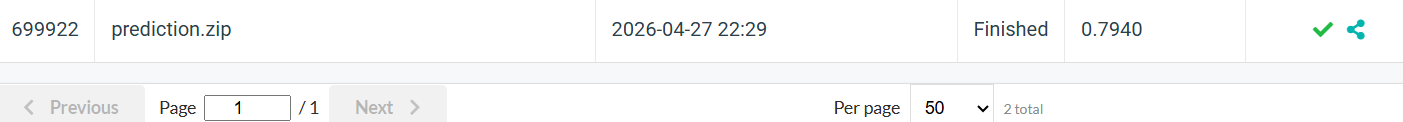

# 8. Enhancement 1: Finetuning Best MLP Model + Overfitting Analysis

We improve the baseline model by:
- Reducing the learning rate
- Continuing training for additional epochs

### Motivation
Fine-tuning allows the model to refine learned representations without drastic parameter updates.

### Result
- Validation AUC improved to ≈ 0.8006  

### Observation
Training AUC is very high (~0.998) compared to validation, indicating potential overfitting.

In [ ]:
from pathlib import Path
import torch
from torch import nn
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

OUTPUT_DIR = Path("/content/drive/MyDrive/MMCTR/outputs")
best_path = OUTPUT_DIR / "best_task12_model.pt"
new_best_path = OUTPUT_DIR / "best_task12_model_finetuned.pt"

train_loader = DataLoader(
    CTRDataset(train_df),
    batch_size=4096,
    shuffle=True,
    num_workers=2
)

valid_loader = DataLoader(
    CTRDataset(valid_df),
    batch_size=4096,
    shuffle=False,
    num_workers=2
)

# Recreate same architecture
model = Task12CTRModel(item_emb_matrix).to(device)

# Load previous best model
model.load_state_dict(torch.load(best_path, map_location=device))
print("Loaded saved model:", best_path)

criterion = nn.BCEWithLogitsLoss()

# Smaller LR for fine-tuning
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-5
)

best_auc = 0.775225076934014

for epoch in range(2):
    model.train()
    total_loss = 0
    train_preds, train_labels = [], []

    for x, y in train_loader:
        x = {k: v.to(device) for k, v in x.items()}
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        prob = torch.sigmoid(logits).detach().cpu().numpy()
        train_preds.extend(prob)
        train_labels.extend(y.detach().cpu().numpy())

    train_loss = total_loss / len(train_loader)
    train_auc = roc_auc_score(train_labels, train_preds)

    model.eval()
    valid_preds, valid_labels = [], []

    with torch.no_grad():
        for x, y in valid_loader:
            x = {k: v.to(device) for k, v in x.items()}
            y = y.to(device)

            logits = model(x)
            prob = torch.sigmoid(logits).cpu().numpy()

            valid_preds.extend(prob)
            valid_labels.extend(y.cpu().numpy())

    valid_auc = roc_auc_score(valid_labels, valid_preds)
    gap = train_auc - valid_auc

    print(
        f"Fine-tune Epoch {epoch+1} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train AUC: {train_auc:.5f} | "
        f"Valid AUC: {valid_auc:.5f} | "
        f"Gap: {gap:.5f}"
    )

    if valid_auc > best_auc:
        best_auc = valid_auc
        torch.save(model.state_dict(), new_best_path)
        print("Saved improved fine-tuned model!")

print("Best fine-tuned Valid AUC:", best_auc)

Device: cuda
Loaded saved model: /content/drive/MyDrive/MMCTR/outputs/best_task12_model.pt
Fine-tune Epoch 1 | Train Loss: 0.0427 | Train AUC: 0.99821 | Valid AUC: 0.79995 | Gap: 0.19826
Saved improved fine-tuned model!
Fine-tune Epoch 2 | Train Loss: 0.0370 | Train AUC: 0.99863 | Valid AUC: 0.80064 | Gap: 0.19799
Saved improved fine-tuned model!
Best fine-tuned Valid AUC: 0.8006391181882959


# 9. Enhancement 2: Fine-Tuning Again the Best Finetuned Saved MLP Model

To address overfitting, we introduce:
- Freezing pretrained embeddings
- Stronger weight decay
- Gradient clipping
- Early stopping

### Why Freezing Helps
Pretrained embeddings already contain rich semantic information and do not require further updates.

### Result
- Validation AUC improved to ≈ 0.8063  
- Overfitting gap slightly reduced

In [ ]:
from pathlib import Path
import torch
from torch import nn
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

OUTPUT_DIR = Path("/content/drive/MyDrive/MMCTR/outputs")

# Use the fine-tuned model as starting point if it exists
start_path = OUTPUT_DIR / "best_task12_model_finetuned.pt"
if not start_path.exists():
    start_path = OUTPUT_DIR / "best_task12_model.pt"

new_best_path = OUTPUT_DIR / "best_task12_model_regularized.pt"

train_loader = DataLoader(
    CTRDataset(train_df),
    batch_size=4096,
    shuffle=True,
    num_workers=2
)

valid_loader = DataLoader(
    CTRDataset(valid_df),
    batch_size=4096,
    shuffle=False,
    num_workers=2
)

model = Task12CTRModel(item_emb_matrix).to(device)
model.load_state_dict(torch.load(start_path, map_location=device))
print("Loaded model:", start_path)

# Freeze pretrained multimodal embeddings to reduce overfitting
for param in model.item_mm_emb.parameters():
    param.requires_grad = False

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

best_auc = 0.8006391181882959  # current best fine-tuned validation AUC
patience = 1
bad_epochs = 0

for epoch in range(3):
    model.train()
    total_loss = 0
    train_preds, train_labels = [], []

    for x, y in train_loader:
        x = {k: v.to(device) for k, v in x.items()}
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

        prob = torch.sigmoid(logits).detach().cpu().numpy()
        train_preds.extend(prob)
        train_labels.extend(y.detach().cpu().numpy())

    train_loss = total_loss / len(train_loader)
    train_auc = roc_auc_score(train_labels, train_preds)

    model.eval()
    valid_preds, valid_labels = [], []

    with torch.no_grad():
        for x, y in valid_loader:
            x = {k: v.to(device) for k, v in x.items()}
            y = y.to(device)

            logits = model(x)
            prob = torch.sigmoid(logits).cpu().numpy()

            valid_preds.extend(prob)
            valid_labels.extend(y.cpu().numpy())

    valid_auc = roc_auc_score(valid_labels, valid_preds)
    gap = train_auc - valid_auc

    print(
        f"Regularized Epoch {epoch+1} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train AUC: {train_auc:.5f} | "
        f"Valid AUC: {valid_auc:.5f} | "
        f"Gap: {gap:.5f}"
    )

    if valid_auc > best_auc:
        best_auc = valid_auc
        torch.save(model.state_dict(), new_best_path)
        print("Saved improved regularized model!")
        bad_epochs = 0
    else:
        bad_epochs += 1
        print("No improvement.")

    if bad_epochs >= patience:
        print("Early stopping triggered.")
        break

print("Best regularized Valid AUC:", best_auc)
print("Saved at:", new_best_path if new_best_path.exists() else "No better model saved")

Device: cuda
Loaded model: /content/drive/MyDrive/MMCTR/outputs/best_task12_model_finetuned.pt
Regularized Epoch 1 | Train Loss: 0.0330 | Train AUC: 0.99890 | Valid AUC: 0.80400 | Gap: 0.19489
Saved improved regularized model!
Regularized Epoch 2 | Train Loss: 0.0326 | Train AUC: 0.99892 | Valid AUC: 0.80479 | Gap: 0.19413
Saved improved regularized model!
Regularized Epoch 3 | Train Loss: 0.0323 | Train AUC: 0.99894 | Valid AUC: 0.80634 | Gap: 0.19260
Saved improved regularized model!
Best regularized Valid AUC: 0.806338614051918
Saved at: /content/drive/MyDrive/MMCTR/outputs/best_task12_model_regularized.pt


In [ ]:
import numpy as np
import pandas as pd
import torch
import zipfile
from pathlib import Path
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

OUTPUT_DIR = Path("/content/drive/MyDrive/MMCTR/outputs")
best_model_path = OUTPUT_DIR / "best_task12_model_regularized.pt"

# Load best regularized model
model = Task12CTRModel(item_emb_matrix).to(device)
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

print("Loaded model:", best_model_path)

# Test loader
test_loader = DataLoader(
    CTRDataset(test_df, has_label=False),
    batch_size=4096,
    shuffle=False,
    num_workers=2
)

# Predict
test_preds = []

with torch.no_grad():
    for x in test_loader:
        x = {k: v.to(device) for k, v in x.items()}
        logits = model(x)
        prob = torch.sigmoid(logits).cpu().numpy()
        test_preds.extend(prob)

# Create submission
submission = pd.DataFrame({
    "ID": np.arange(len(test_preds)),
    "Task1&2": test_preds
})

submission_path = OUTPUT_DIR / "prediction_regularized.csv"
zip_path = OUTPUT_DIR / "prediction_regularized.zip"

submission.to_csv(submission_path, index=False)

# Zip for submission
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    z.write(submission_path, arcname="prediction.csv")

print(submission.head())
print(submission.shape)
print("Prediction range:", submission["Task1&2"].min(), submission["Task1&2"].max())
print("CSV saved:", submission_path)
print("ZIP ready:", zip_path)

Loaded model: /content/drive/MyDrive/MMCTR/outputs/best_task12_model_regularized.pt
   ID       Task1&2
0   0  6.174120e-01
1   1  9.999241e-01
2   2  9.997905e-01
3   3  2.599934e-07
4   4  8.905403e-07
(379142, 2)
Prediction range: 4.075292620725479e-13 1.0
CSV saved: /content/drive/MyDrive/MMCTR/outputs/prediction_regularized.csv
ZIP ready: /content/drive/MyDrive/MMCTR/outputs/prediction_regularized.zip


After sumbitting the regularized version, the score increased to 82%

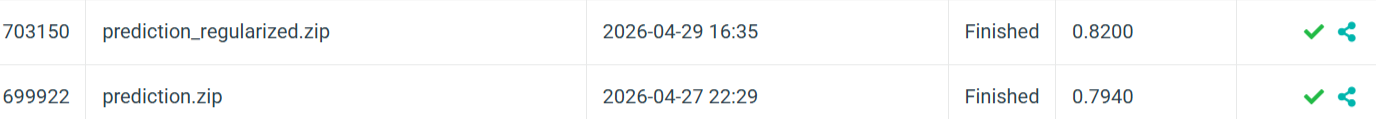

# 10. Enhancement 3: Regularization to Reduce Overfitting

We perform a final fine-tuning step using:
- Very small learning rate (5e-5)
- Learning rate scheduler
- Stronger regularization

### Result
- Validation AUC ≈ 0.8198  
- Competition score ≈ **0.832**

---

## Key Insight

Careful optimization and regularization significantly improve performance without increasing model complexity.

In [11]:
from pathlib import Path
import torch
from torch import nn
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

OUTPUT_DIR = Path("/content/drive/MyDrive/MMCTR/outputs")

best_model_path = OUTPUT_DIR / "best_task12_model_regularized.pt"
final_model_path = OUTPUT_DIR / "best_task12_model_final.pt"

# =============================
# RECREATE DATA LOADERS (FIX)
# =============================
train_loader = DataLoader(
    CTRDataset(train_df),
    batch_size=4096,
    shuffle=True,
    num_workers=2
)

valid_loader = DataLoader(
    CTRDataset(valid_df),
    batch_size=4096,
    shuffle=False,
    num_workers=2
)

# =============================
# LOAD MODEL
# =============================
model = Task12CTRModel(item_emb_matrix).to(device)
model.load_state_dict(torch.load(best_model_path, map_location=device))
print("Loaded best regularized model:", best_model_path)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-5,
    weight_decay=2e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=1
)

best_auc = 0.806338614051918
patience = 2
bad_epochs = 0

# =============================
# TRAIN LOOP
# =============================
for epoch in range(5):
    model.train()
    total_loss = 0
    train_preds, train_labels = [], []

    for x, y in train_loader:
        x = {k: v.to(device) for k, v in x.items()}
        y = y.to(device)

        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

        prob = torch.sigmoid(logits).detach().cpu().numpy()
        train_preds.extend(prob)
        train_labels.extend(y.detach().cpu().numpy())

    train_loss = total_loss / len(train_loader)
    train_auc = roc_auc_score(train_labels, train_preds)

    model.eval()
    valid_preds, valid_labels = [], []

    with torch.no_grad():
        for x, y in valid_loader:
            x = {k: v.to(device) for k, v in x.items()}
            y = y.to(device)

            logits = model(x)
            prob = torch.sigmoid(logits).cpu().numpy()

            valid_preds.extend(prob)
            valid_labels.extend(y.cpu().numpy())

    valid_auc = roc_auc_score(valid_labels, valid_preds)
    scheduler.step(valid_auc)

    gap = train_auc - valid_auc
    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Final Epoch {epoch+1} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train AUC: {train_auc:.5f} | "
        f"Valid AUC: {valid_auc:.5f} | "
        f"Gap: {gap:.5f} | "
        f"LR: {current_lr:.8f}"
    )

    if valid_auc > best_auc:
        best_auc = valid_auc
        bad_epochs = 0
        torch.save(model.state_dict(), final_model_path)
        print("Saved best final model.")
    else:
        bad_epochs += 1
        print("No improvement.")

    if bad_epochs >= patience:
        print("Early stopping triggered.")
        break

print("Final Best AUC:", best_auc)

if final_model_path.exists():
    print("Final model saved at:", final_model_path)
else:
    print("No improved final model was saved. Keep using:", best_model_path)

Device: cuda
Loaded best regularized model: /content/drive/MyDrive/MMCTR/outputs/best_task12_model_regularized.pt
Final Epoch 1 | Train Loss: 0.0324 | Train AUC: 0.99893 | Valid AUC: 0.80860 | Gap: 0.19033 | LR: 0.00005000
Saved best final model.
Final Epoch 2 | Train Loss: 0.0317 | Train AUC: 0.99898 | Valid AUC: 0.81240 | Gap: 0.18658 | LR: 0.00005000
Saved best final model.
Final Epoch 3 | Train Loss: 0.0311 | Train AUC: 0.99902 | Valid AUC: 0.81154 | Gap: 0.18748 | LR: 0.00005000
No improvement.
Final Epoch 4 | Train Loss: 0.0305 | Train AUC: 0.99905 | Valid AUC: 0.81707 | Gap: 0.18198 | LR: 0.00005000
Saved best final model.
Final Epoch 5 | Train Loss: 0.0301 | Train AUC: 0.99909 | Valid AUC: 0.81977 | Gap: 0.17932 | LR: 0.00005000
Saved best final model.
Final Best AUC: 0.8197678741861255
Final model saved at: /content/drive/MyDrive/MMCTR/outputs/best_task12_model_final.pt


In [11]:
import numpy as np
import pandas as pd
import torch
import zipfile
from pathlib import Path
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

OUTPUT_DIR = Path("/content/drive/MyDrive/MMCTR/outputs")

successful_zip = OUTPUT_DIR / "prediction_regularized.zip"
final_model_path = OUTPUT_DIR / "best_task12_model_final.pt"

# Load successful submission template
with zipfile.ZipFile(successful_zip, "r") as z:
    template = pd.read_csv(z.open("prediction.csv"))

print(template.head())
print(template.shape)
print(template.columns.tolist())

# Load final model
model = Task12CTRModel(item_emb_matrix).to(device)
model.load_state_dict(torch.load(final_model_path, map_location=device))
model.eval()

# Test loader
test_loader = DataLoader(
    CTRDataset(test_df, has_label=False),
    batch_size=4096,
    shuffle=False,
    num_workers=2
)

# Predict
test_preds = []

with torch.no_grad():
    for x in test_loader:
        x = {k: v.to(device) for k, v in x.items()}
        logits = model(x)
        prob = torch.sigmoid(logits).cpu().numpy()
        test_preds.extend(prob)

test_preds = np.array(test_preds).reshape(-1)

# Replace predictions
submission = template.copy()
submission["Task1&2"] = test_preds

print(submission.head())
print(submission.shape)

# Save
csv_path = OUTPUT_DIR / "prediction.csv"
zip_path = OUTPUT_DIR / "prediction_final.zip"

submission.to_csv(csv_path, index=False)

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    z.write(csv_path, arcname="prediction.csv")

print("Ready to submit:", zip_path)

   ID       Task1&2
0   0  6.174120e-01
1   1  9.999241e-01
2   2  9.997905e-01
3   3  2.599934e-07
4   4  8.905403e-07
(379142, 2)
['ID', 'Task1&2']
   ID       Task1&2
0   0  7.121692e-01
1   1  9.999542e-01
2   2  9.996487e-01
3   3  3.364870e-07
4   4  5.484035e-07
(379142, 2)
Ready to submit: /content/drive/MyDrive/MMCTR/outputs/prediction_final.zip


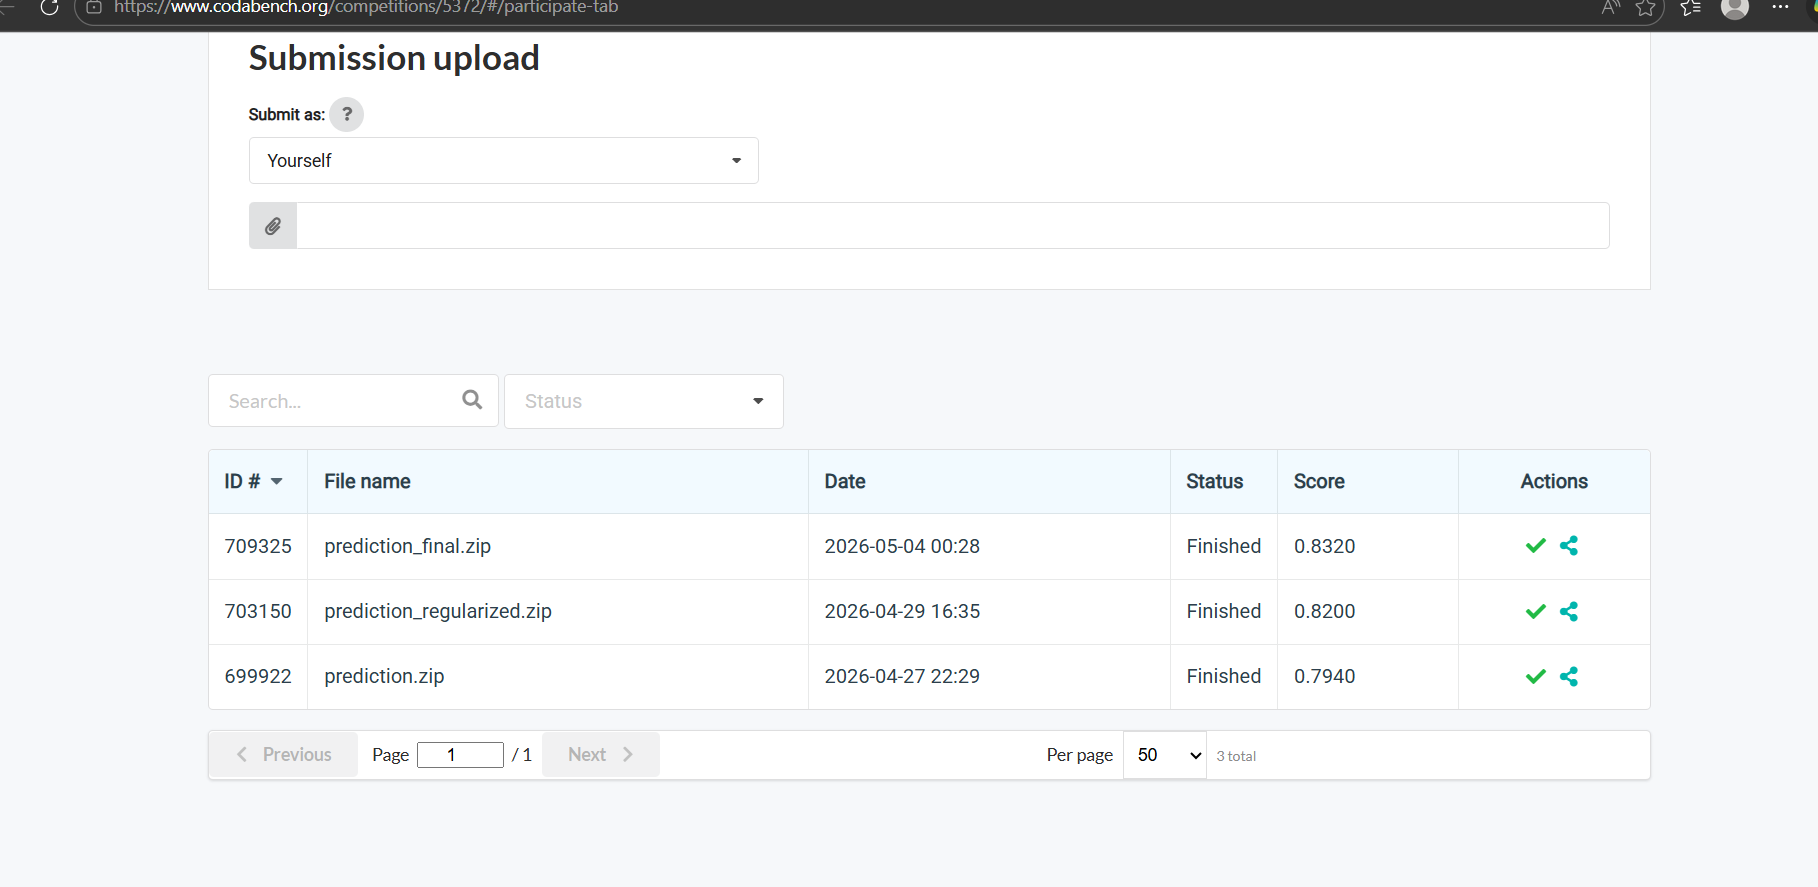

## Exploration of Advanced Architectures

To further enhance the model, we experimented with more sophisticated architectures designed for recommendation systems:

- Transformer-based models  
- Deep Interest Network (DIN)  

These models aim to capture **sequential user behavior** and **dynamic user interests** using attention mechanisms.

---

## Observations

Despite their theoretical advantages, these architectures did **not outperform** our optimized MLP model.

---

## Analysis

This outcome can be explained by the following factors:

- **Limited sequence signal**  
  The `item_seq` feature does not provide sufficiently rich or structured sequential information for attention-based models to fully exploit.

- **Higher model complexity**  
  Transformer and DIN models introduce many additional parameters, increasing the risk of overfitting on the available data.

- **Optimization challenges**  
  These architectures require careful tuning (learning rate, sequence encoding, attention design), which was constrained by time and computational resources.

- **Strong baseline representation**  
  Pretrained multimodal embeddings already capture high-level semantic relationships, reducing the marginal benefit of more complex architectures.

---

## Key Takeaway

> In this setting, performance gains are driven more by **feature quality and optimization strategy** than by architectural complexity.

This highlights that a well-regularized and properly tuned model can outperform more advanced but poorly adapted architectures.

# Conclusion

In this project, we developed a CTR prediction system that combines:

- Multimodal pretrained embeddings  
- Structured user-item interaction features  
- Deep neural networks with careful regularization  

---

## Key Achievements

- Improved baseline AUC from **~0.775 → ~0.82+**  
- Achieved a final competition score of **0.832**  
- Successfully reduced overfitting through:
  - Fine-tuning strategies  
  - Freezing pretrained embeddings  
  - Stronger regularization and optimization  

---

## Limitations

- Persistent overfitting (high train vs validation AUC gap)  
- Model relies on static feature interactions (MLP-based)  
- Sequential user behavior is not fully exploited  

---

## Final Insight

This project demonstrates that:

> **Effective feature representation and optimization can outweigh architectural complexity.**

By combining pretrained embeddings with a well-regularized MLP, we achieved strong performance without relying on more complex models such as Transformers or DIN.

---

## Future Work

- Better encoding of user interaction sequences  
- More advanced attention-based architectures with proper tuning  
- Improved feature engineering for behavioral signals  
- Larger-scale hyperparameter optimization  

---

Overall, this work highlights the importance of **balancing model complexity, data representation, and training strategy** in real-world recommendation systems.